In [2]:
setwd("/well/lindgren-ukbb/projects/ukbb-11867/flassen/projects/KO/wes_ko_ukbb")
devtools::load_all("utils/modules/R/gwastools")
library(data.table)


i Loading gwastools



In [3]:
#d <- fread("data/simulation/saige/step2/ukb_eur_h2_0.00_var_0.00_0.00_pi_0.01_0.01_K0.1_chr22_y_1_pLoF_damaging_missense.txt")

In [4]:
#p <- fread("data/simulation/phenotypes/_1_cols.tsv.gz")

In [5]:
#d <- fread("data/simulation/phenotypes/ukb_eur_h2_0.001_var_0.10_99.0_pi_0.20_0.20_K0.1_seed504_chr22_1_cols.tsv.gz")
#d <- fread("data/simulation/phenotypes/ukb_eur_h2_0.001_var_0.10_99.0_pi_0.20_0.20_K0.1_seed604_chr22_1_cols.tsv.gz")

In [12]:
#d <- fread("data/simulation/phenotypes/ukb_eur_h2_0.001_var_10.0_0.10_pi_0.20_0.20_K0.1_seed501_chr22_1_cols.tsv.gz")
d <- fread("data/simulation/phenotypes/ukb_eur_h2_0.001_var_0.10_1.00_pi_0.20_0.20_K0.1_seed602_chr22_5_cols.tsv.gz")

In [13]:
print(paste("additive: ", var(d$y_no_noise) / var(d$y_no_noise_add)))
print(paste("recessive: ", var(d$y_no_noise) / var(d$y_no_noise_rec)))

[1] "additive:  1.11873962716687"
[1] "recessive:  13.4599709550611"


In [14]:
var(d$y_no_noise)

[1] 0.08301403

In [15]:
mean(d$y_no_noise_add)
mean(d$y_no_noise_rec)

[1] 2.36161e-07

[1] 0.0162676

# Simulate absence of effects

In [9]:
#pattern <- "ukb_eur_h2_0.00_var_0.00_0.00_pi_0.01_0.01_K0.1_chr22"
#pattern <- "ukb_eur_h2_0.30_var_0.01_1_pi_1.00_1.00_K0.1_chr22"
pattern <- "ukb_eur_h2_0.30_var_0.01_0.01_pi_1.00_1.00_K0.1_chr22"
files <- list.files("data/simulation/saige/step2/binary", pattern = ".txt$", full.names = TRUE)
#files <- files[!grepl("index", files)][1:49]
tail(files, n = 2)

[1] "data/simulation/saige/step2/binary/ukb_eur_h2_0.001_var_10.0_0.10_pi_0.20_0.20_K0.1_seed501_chr22_case_4_pLoF_damaging_missense.txt"
[2] "data/simulation/saige/step2/binary/ukb_eur_h2_0.001_var_10.0_0.10_pi_0.20_0.20_K0.1_seed501_chr22_case_5_pLoF_damaging_missense.txt"

In [19]:
# get corresponding simulation file
grab_sim_file <- function(file, simdir = "data/simulation/phenotypes/", hail = "cols"){
    f <- gsub("(_pLoF_damaging_missense.txt)|(case_)","",basename(file))
    f <- paste0(simdir,f, "_",hail,".tsv.gz")
    if (!file.exists(f)) stop(paste(f, "could not be found!"))
    return(f)
}

get_qq_df <- function(files, get_sim_file = FALSE){
    ribbon_p <- 0.95
    d <- do.call(rbind, lapply(files, function(f){
        stopifnot(file.exists(f))
        d <- fread(f)
        
        extracted_pi <- gsub("(pi_)|(_K)","",stringr::str_extract(basename(f), "pi.+K"))
        extracted_vars <- gsub("(var_)|(_pi)","",stringr::str_extract(basename(f), "var.+pi"))
        pis <- unlist(strsplit(extracted_pi, split = '_'))
        vars <- unlist(strsplit(extracted_vars, split = '_'))
        
        if (nrow(d) > 0){
            
            # get qq-plot data
            d$p.value.expt <- get_expected_p(d$p.value, na.rm = TRUE)
            n <- length(d$p.value)
            dt <- data.table(
                ensembl_gene_id = d$MarkerID[order(d$p.value)],
                pvalue.observed = -log10(sort(d$p.value)),
                pvalue.expected = -log10(sort(d$p.value.expt)),
                clower = -log10(qbeta(p = (1 - ribbon_p) / 2, shape2 = n:1, shape1 = 1:n)),
                cupper = -log10(qbeta(p = (1 + ribbon_p) / 2, shape2 = n:1, shape1 = 1:n)),
                #gsub("(pLoF_damaging_missense.txt)|(ukb_eur_)|(K0.1_)|(_chr22)", "", basename(f)),
                #phenofile = gsub("_pLoF_damaging_missense.txt","_phenos.tsv.gz", basename)
                h2 = as.numeric(gsub("(h2_)|(_var)","",stringr::str_extract(basename(f), "h2.+var"))),
                seed = as.numeric(gsub("(seed)|(_chr)","",stringr::str_extract(basename(f), "seed.+chr"))),
                pi_1 = as.numeric(pis[1]),
                pi_2 = as.numeric(pis[2]),
                var_1 = as.numeric(vars[1]),
                var_2 = as.numeric(vars[2])
            )
            
            # grab actual file used for simulation
            if (get_sim_file){
                simfile <- grab_sim_file(f)
                dsim <- fread(simfile)
                dt$sim_h2 <- round(var(dsim$y_no_noise_rescaled), 5)
                dt$sim_y <- round(var(dsim$y))
                dt$sim_cases <- sum(dsim$case)
                dt$sim_controls <- sum(!dsim$case)
                dt$var_by_rec <- var(dsim$y_no_noise_rec) / (var(dsim$y_no_noise_add) + var(dsim$y_no_noise_rec))
                dt$var_by_rec <- round(dt$var_by_rec, 4)
            }
            
            dt$fname <- basename(f)
            return(dt)
        } else {
            return(NULL)
        }
    }))
    d$label <- factor(paste0("sim",d$seed), levels = paste0("sim",1:100))
    return(d)
}

In [8]:
#d <- get_qq_df(files)

In [9]:
options(repr.plot.width=16, repr.plot.height=12)
bonf <- 0.05 / (length(unique(d$ensembl_gene_id)) * length(unique(d$seed)))
ggplot(d, aes(x=pvalue.expected, y=pvalue.observed, ymax=cupper, ymin=clower, group = label, color = label)) +
    geom_ribbon(fill="grey80", color="black", alpha = 0.1, linetype = 'dashed') +
    geom_line() +
    geom_point() +
    geom_abline(linetype = 'dotted') + 
    scale_x_continuous(breaks=scales::pretty_breaks(n=5)) +
    scale_y_continuous(breaks=scales::pretty_breaks(n=5)) +
    xlab(expression(paste(-log[10],'(Expected P-value)' ))) +
    ylab(expression(paste(-log[10],'(Observed P-value)' ))) +
    #geom_hline(yintercept = -log10(bonf), linetype = 'dashed', color = 'red') +
    ggtitle("Simulation of absence of effects") +
    facet_wrap(~label) +
    theme_bw() +
    theme(
        axis.text=element_text(size=14),
        axis.title=element_text(size=14,face="bold"),
        axis.title.x = element_text(margin=ggplot2::margin(t=16)),
        axis.title.y = element_text(margin=ggplot2::margin(r=16)),
        plot.title = element_text(hjust=0.5),
        plot.subtitle = element_text(hjust=0.5),
        legend.position="none"
    )

ERROR: Error in unique(d$ensembl_gene_id): object 'd' not found


# Simulate additive effects

In [20]:
pattern <- "seed60"
files <- list.files("data/simulation/saige/step2/binary", pattern = pattern, full.names = TRUE)
files <- files[!grepl("index", files)]
head(files)

[1] "data/simulation/saige/step2/binary/ukb_eur_h2_0.001_var_0.10_0.10_pi_0.20_0.20_K0.1_seed601_chr22_case_1_pLoF_damaging_missense.txt"
[2] "data/simulation/saige/step2/binary/ukb_eur_h2_0.001_var_0.10_0.10_pi_0.20_0.20_K0.1_seed601_chr22_case_2_pLoF_damaging_missense.txt"
[3] "data/simulation/saige/step2/binary/ukb_eur_h2_0.001_var_0.10_0.10_pi_0.20_0.20_K0.1_seed601_chr22_case_3_pLoF_damaging_missense.txt"
[4] "data/simulation/saige/step2/binary/ukb_eur_h2_0.001_var_0.10_0.10_pi_0.20_0.20_K0.1_seed601_chr22_case_4_pLoF_damaging_missense.txt"
[5] "data/simulation/saige/step2/binary/ukb_eur_h2_0.001_var_0.10_0.10_pi_0.20_0.20_K0.1_seed601_chr22_case_5_pLoF_damaging_missense.txt"
[6] "data/simulation/saige/step2/binary/ukb_eur_h2_0.001_var_0.10_1.00_pi_0.20_0.20_K0.1_seed602_chr22_case_1_pLoF_damaging_missense.txt"

In [21]:
d <- get_qq_df(files, get_sim_file = FALSE)

In [22]:
get_entry_file <- function(x){
    directory <- "data/simulation/phenotypes/"
    y <- gsub("(_case)","",x)
    y <- gsub("_pLoF_damaging_missense.txt","_entries.tsv.gz",y)
    return(paste0(directory,y))
}

In [23]:
d$fentry <- get_entry_file(d$fname)
file_df <- d[,c("fname","fentry")]
file_df <- file_df[!duplicated(file_df)]
file_df$h2 <- as.numeric(gsub("(h2_)|(_var)","",stringr::str_extract(basename(file_df$fname), "h2.+var")))
file_df$seed <- as.numeric(gsub("(seed)|(_chr)","",stringr::str_extract(basename(file_df$fname), "seed.+chr")))
file_df$id <- as.numeric(gsub("(case_)|(_pLoF)","",stringr::str_extract(basename(file_df$fname), "case.+pLoF")))

In [24]:
lst <- lapply(1:nrow(file_df), function(idx){
    write(idx, stderr())
    file_entry <- file_df$fentry[idx]
    file_saige <- file_df$fname[idx]
    command <- paste("zcat",file_entry,"| grep -v NA")
    entry_dt <- fread(cmd = command)
    
    # get knockout count
    ko_dt <- data.table(table(entry_dt$rsid, entry_dt$pKO != 0))
    ko_dt <- ko_dt[ko_dt$V2 == TRUE,]
    ko_dt <- ko_dt[,c("V1","N")]
    colnames(ko_dt) <- c("ensembl_gene_id","N")
    
    
    # get beta/theta estimates
    entry_dt <- entry_dt[,c("rsid","theta", "beta")]
    entry_dt <- entry_dt[!duplicated(entry_dt),]
    colnames(entry_dt)[1] <- "ensembl_gene_id"
    
    # get pvalue observed
    saige_dt <- d[d$fname %in% file_saige,]
    saige_dt <- saige_dt[,c("ensembl_gene_id","pvalue.observed")]
    saige_dt <- saige_dt[!duplicated(saige_dt),]
    dt <- merge(entry_dt, saige_dt)
    dt <- merge(dt, ko_dt, all.x = TRUE)
    dt$seed <- file_df$seed[idx]
    dt$h2 <- file_df$h2[idx]
    dt$analysis <- basename(file_saige)
    dt$id <- file_df$id[idx]
    return(dt)
})

In [25]:
combined <- do.call(rbind, lst)
combined$id <- factor(combined$id)
#combined <- combined[combined$h2 != 0.002]

In [26]:
sum(combined$theta == combined$beta)/nrow(combined)

[1] 0.8011429

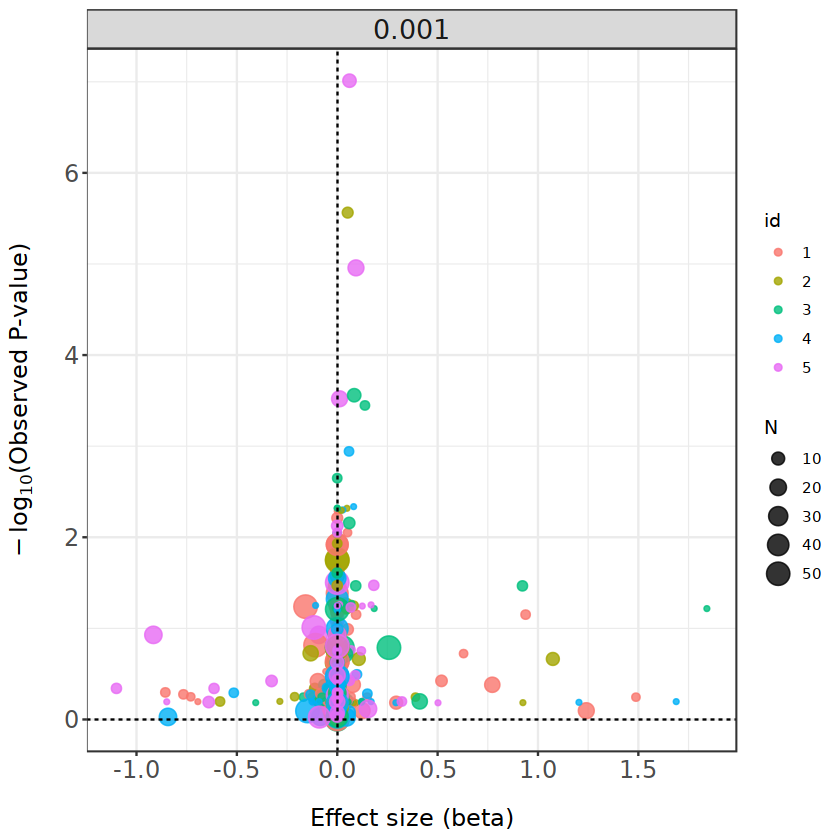

In [28]:
ggplot(combined, aes(x=beta, y=pvalue.observed, size = N, color = id)) +
    geom_point(alpha = 0.8) +
    theme_bw() +
    geom_vline(xintercept = 0, linetype = 'dashed') +
    geom_hline(yintercept = 0, linetype = 'dashed') +
    scale_x_continuous(breaks=scales::pretty_breaks(n=5)) +
    scale_y_continuous(breaks=scales::pretty_breaks(n=5)) +
    ylab(expression(paste(-log[10],'(Observed P-value)' ))) +
    xlab("Effect size (beta)") +
    facet_wrap(~h2, scales = "free_y") +
    theme(
        axis.text=element_text(size=14),
        axis.title=element_text(size=14),
        axis.title.x = element_text(margin=ggplot2::margin(t=16)),
        axis.title.y = element_text(margin=ggplot2::margin(r=16)),
        plot.title = element_text(hjust=0.5),
        plot.subtitle = element_text(hjust=0.5),
        strip.text = element_text(size=16),
        legend.position="right"
    )

In [ ]:
plot(lst[[1]]$theta, lst[[1]]$pvalue.observed)

In [ ]:

#fname <- "ukb_eur_h2_0.01_var_0.10_99.0_pi_0.20_0.20_K0.1_seed404_chr22_1_entries.tsv.gz"
fname <- "ukb_eur_h2_0.01_var_0.10_0.10_pi_0.20_0.20_K0.1_seed401_chr22_1_entries.tsv.gz"
fname <- "ukb_eur_h2_0.001_var_0.10_99.0_pi_0.20_0.20_K0.1_seed601_chr22_case_1_pLoF_damaging_missense.txt"
path <- paste0(directory, fname)
command <- paste("zcat",path,"| grep -v NA")
d <- fread(cmd = command)

In [112]:
table(d$case, d$beta != 0)
table(d$case, d$theta != 0)

< table of extent 0 x 0 >

< table of extent 0 x 0 >

In [113]:
d <- d[,c("beta", "theta", "rsid")]
d <- d[!duplicated(d),]
colnames(d) <- c("sim_beta","sim_theta", "MarkerID")

ERROR: Error in `[.data.table`(d, , c("beta", "theta", "rsid")): column(s) not found: beta, theta, rsid


In [114]:
fname <- "ukb_eur_h2_0.01_var_0.10_0.10_pi_0.20_0.20_K0.1_seed401_chr22_1_cols.tsv.gz"
path <- paste0(directory, fname)
command <- paste("zcat",path,"| grep -v NA")
cols <- fread(cmd = command)
var(cols$y_no_noise_add); var(cols$y_no_noise_rec); var(cols$y_no_noise); var(cols$y_no_noise_rescaled); var(cols$y)

ERROR: Error in paste0(directory, fname): object 'directory' not found


In [115]:
plot(
    y=cols$y_no_noise, 
    x=cols$y_no_noise[order(cols$y_no_noise)], 
    col = ifelse(cols$case, "red","blue")
)

ERROR: Error in plot(y = cols$y_no_noise, x = cols$y_no_noise[order(cols$y_no_noise)], : object 'cols' not found


In [116]:
#path <- "data/simulation/saige/step2/binary/ukb_eur_h2_0.01_var_0.10_99.0_pi_0.20_0.20_K0.1_seed404_chr22_case_1_pLoF_damaging_missense.txt"
path <- "data/simulation/saige/step2/binary/ukb_eur_h2_0.01_var_0.10_0.10_pi_0.20_0.20_K0.1_seed401_chr22_case_1_pLoF_damaging_missense.txt"
dt <- fread(path)
dt <- merge(d, dt)
plot(dt$sim_beta, -log10(dt$p.value))
plot(dt$sim_theta, -log10(dt$p.value))

ERROR: Error in merge.data.table(d, dt): A non-empty vector of column names for `by` is required.


In [117]:
#options(repr.plot.width=8, repr.plot.height=6)
#ggplot(d, aes(x=log10(var_2), y=var_by_rec)) +
#    geom_point() +
#    theme_bw() +
#    ylab("% variance explained by recessive effects") + 
#    xlab("log10(Variable V2)")

#fname <- grab_sim_file(d$fname[1], hail = 'entries')
#fname
#cmd <- paste("zcat", fname, "| grep -v NA")
#cmd
#test <- fread(cmd = cmd)
#test

In [136]:
d$id <- as.numeric(gsub("(case_)|(_pLoF)","",stringr::str_extract(basename(d$fname), "case.+pLoF")))
d$id <- factor(d$id)
d_plot <- d[d$h2 != 0.002]

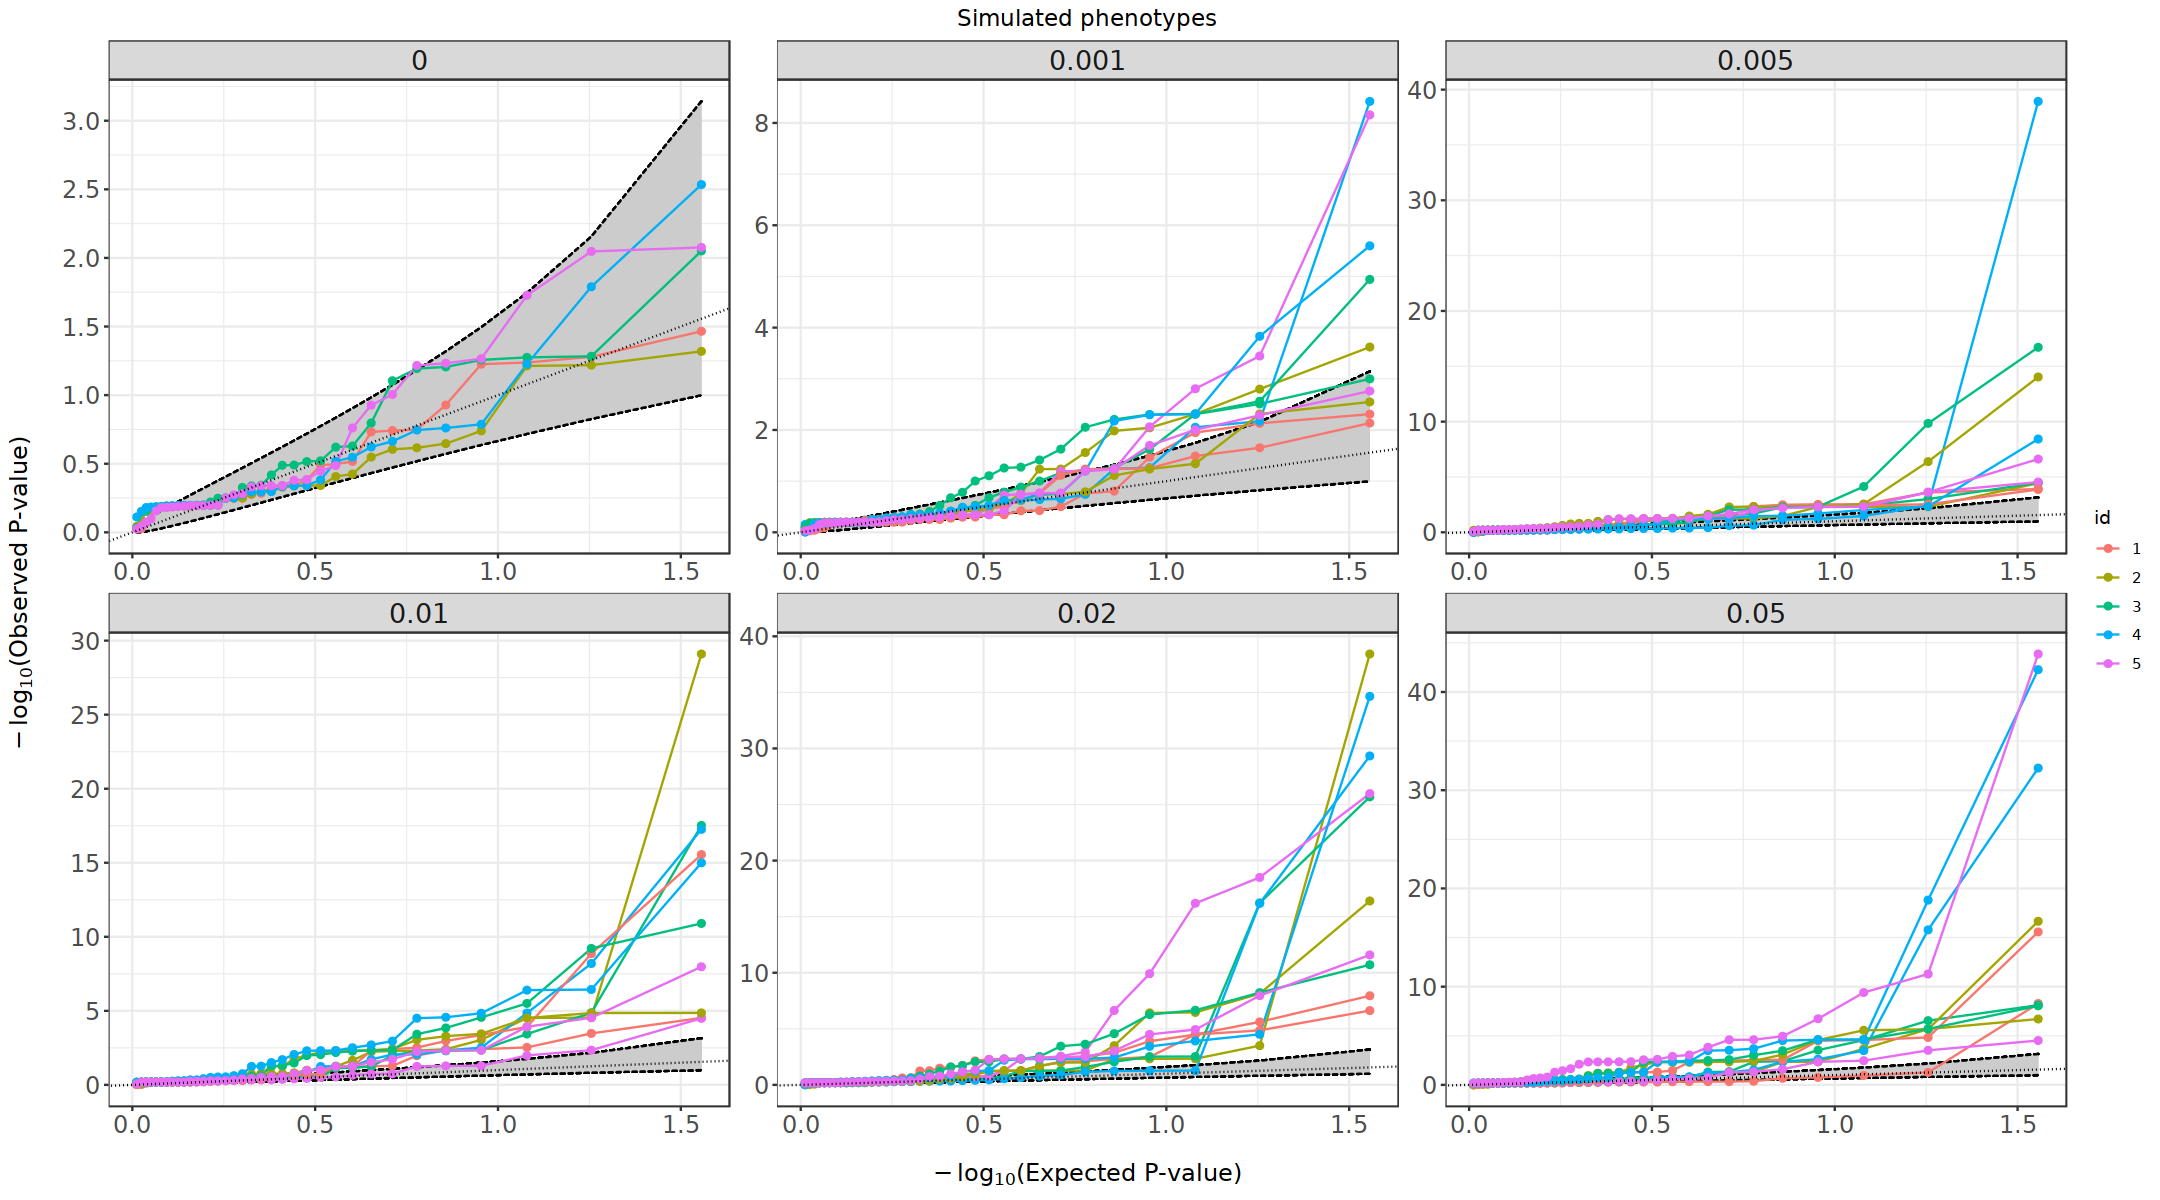

In [137]:
options(repr.plot.width=18, repr.plot.height=10)
#bonf <- 0.05 / (length(unique(d$ensembl_gene_id)) * length(unique(d$seed)))
ggplot(d_plot, aes(x=pvalue.expected, y=pvalue.observed, ymax=cupper, ymin=clower, group = fname, color = id)) +
    geom_ribbon(fill="grey80", color="black", alpha = 0.7, linetype = 'dashed') +
    geom_line() +
    geom_point() +
    geom_abline(linetype = 'dotted') + 
    scale_x_continuous(breaks=scales::pretty_breaks(n=5)) +
    scale_y_continuous(breaks=scales::pretty_breaks(n=5)) +
    xlab(expression(paste(-log[10],'(Expected P-value)' ))) +
    ylab(expression(paste(-log[10],'(Observed P-value)' ))) +
    #geom_hline(yintercept = -log10(bonf), linetype = 'dashed', color = 'red') +
    ggtitle("Simulated phenotypes") +
    facet_wrap(~h2, scales = 'free') +
    theme_bw() +
    theme(
        axis.text=element_text(size=14),
        axis.title=element_text(size=14,face="bold"),
        axis.title.x = element_text(margin=ggplot2::margin(t=16)),
        axis.title.y = element_text(margin=ggplot2::margin(r=16)),
        plot.title = element_text(hjust=0.5),
        plot.subtitle = element_text(hjust=0.5),
            strip.text = element_text(size=16),
        legend.position="right"
    )

In [47]:
x <- files
x <- x[grepl("h2_0.001",x)]
x <- x[grepl("var_0.10_10.0",x)]
files

[1] "data/simulation/saige/step2/binary/ukb_eur_h2_0.001_var_0.10_0.10_pi_0.20_0.20_K0.1_seed401_chr22_case_1_pLoF_damaging_missense.txt"
 [2] "data/simulation/saige/step2/binary/ukb_eur_h2_0.001_var_0.10_0.10_pi_0.20_0.20_K0.1_seed401_chr22_case_2_pLoF_damaging_missense.txt"
 [3] "data/simulation/saige/step2/binary/ukb_eur_h2_0.001_var_0.10_0.10_pi_0.20_0.20_K0.1_seed401_chr22_case_3_pLoF_damaging_missense.txt"
 [4] "data/simulation/saige/step2/binary/ukb_eur_h2_0.001_var_0.10_0.10_pi_0.20_0.20_K0.1_seed401_chr22_case_4_pLoF_damaging_missense.txt"
 [5] "data/simulation/saige/step2/binary/ukb_eur_h2_0.001_var_0.10_0.10_pi_0.20_0.20_K0.1_seed401_chr22_case_5_pLoF_damaging_missense.txt"
 [6] "data/simulation/saige/step2/binary/ukb_eur_h2_0.001_var_0.10_1.00_pi_0.20_0.20_K0.1_seed402_chr22_case_1_pLoF_damaging_missense.txt"
 [7] "data/simulation/saige/step2/binary/ukb_eur_h2_0.001_var_0.10_1.00_pi_0.20_0.20_K0.1_seed402_chr22_case_2_pLoF_damaging_missense.txt"
 [8] "data/simulation/saige/step2/binary/ukb_eur_h2_0.001_var_0.10_1.00_pi_0.20_0.20_K0.1_seed402_chr22_case_3_pLoF_damaging_missense.txt"
 [9] "data/simulation/saige/step2/binary/ukb_eur_h2_0.001_var_0.10_1.00_pi_0.20_0.20_K0.1_seed402_chr22_case_4_pLoF_damaging_missense.txt"
[10] "data/simulation/saige/step2/binary/ukb_eur_h2_0.001_var_0.10_1.00_pi_0.20_0.20_K0.1_seed402_chr22_case_5_pLoF_damaging_missense.txt"
[11] "data/simulation/saige/step2/binary/ukb_eur_h2_0.001_var_0.10_10.0_pi_0.20_0.20_K0.1_seed403_chr22_case_1_pLoF_damaging_missense.txt"
[12] "data/simulation/saige/step2/binary/ukb_eur_h2_0.001_var_0.10_10.0_pi_0.20_0.20_K0.1_seed403_chr22_case_2_pLoF_damaging_missense.txt"
[13] "data/simulation/saige/step2/binary/ukb_eur_h2_0.001_var_0.10_10.0_pi_0.20_0.20_K0.1_seed403_chr22_case_3_pLoF_damaging_missense.txt"
[14] "data/simulation/saige/step2/binary/ukb_eur_h2_0.001_var_0.10_10.0_pi_0.20_0.20_K0.1_seed403_chr22_case_4_pLoF_damaging_missense.txt"
[15] "data/simulation/saige/step2/binary/ukb_eur_h2_0.001_var_0.10_10.0_pi_0.20_0.20_K0.1_seed403_chr22_case_5_pLoF_damaging_missense.txt"
[16] "data/simulation/saige/step2/binary/ukb_eur_h2_0.001_var_0.10_99.0_pi_0.20_0.20_K0.1_seed404_chr22_case_1_pLoF_damaging_missense.txt"
[17] "data/simulation/saige/step2/binary/ukb_eur_h2_0.001_var_0.10_99.0_pi_0.20_0.20_K0.1_seed404_chr22_case_2_pLoF_damaging_missense.txt"
[18] "data/simulation/saige/step2/binary/ukb_eur_h2_0.001_var_0.10_99.0_pi_0.20_0.20_K0.1_seed404_chr22_case_3_pLoF_damaging_missense.txt"
[19] "data/simulation/saige/step2/binary/ukb_eur_h2_0.001_var_0.10_99.0_pi_0.20_0.20_K0.1_seed404_chr22_case_4_pLoF_damaging_missense.txt"
[20] "data/simulation/saige/step2/binary/ukb_eur_h2_0.001_var_0.10_99.0_pi_0.20_0.20_K0.1_seed404_chr22_case_5_pLoF_damaging_missense.txt"
[21] "data/simulation/saige/step2/binary/ukb_eur_h2_0.005_var_0.10_0.10_pi_0.20_0.20_K0.1_seed401_chr22_case_1_pLoF_damaging_missense.txt"
[22] "data/simulation/saige/step2/binary/ukb_eur_h2_0.005_var_0.10_0.10_pi_0.20_0.20_K0.1_seed401_chr22_case_2_pLoF_damaging_missense.txt"
[23] "data/simulation/saige/step2/binary/ukb_eur_h2_0.005_var_0.10_0.10_pi_0.20_0.20_K0.1_seed401_chr22_case_3_pLoF_damaging_missense.txt"
[24] "data/simulation/saige/step2/binary/ukb_eur_h2_0.005_var_0.10_0.10_pi_0.20_0.20_K0.1_seed401_chr22_case_4_pLoF_damaging_missense.txt"
[25] "data/simulation/saige/step2/binary/ukb_eur_h2_0.005_var_0.10_0.10_pi_0.20_0.20_K0.1_seed401_chr22_case_5_pLoF_damaging_missense.txt"
[26] "data/simulation/saige/step2/binary/ukb_eur_h2_0.005_var_0.10_1.00_pi_0.20_0.20_K0.1_seed402_chr22_case_1_pLoF_damaging_missense.txt"
[27] "data/simulation/saige/step2/binary/ukb_eur_h2_0.005_var_0.10_1.00_pi_0.20_0.20_K0.1_seed402_chr22_case_2_pLoF_damaging_missense.txt"
[28] "data/simulation/saige/step2/binary/ukb_eur_h2_0.005_var_0.10_1.00_pi_0.20_0.20_K0.1_seed402_chr22_case_3_pLoF_damaging_missense.txt"
[29] "data/simulation/saige/step2/binary/ukb_eur_h2_0.005_var_0.10_1.00_pi_0.20_0.20_K0.1_seed402_chr22_case_

Warning message in writeBin(bfr, con = out, size = 1L):
"problem writing to connection"
Warning message in writeBin(bfr, con = out, size = 1L):
"problem writing to connection"
Warning message in writeBin(bfr, con = out, size = 1L):
"problem writing to connection"
Warning message in writeBin(bfr, con = out, size = 1L):
"problem writing to connection"
Warning message in writeBin(bfr, con = out, size = 1L):
"problem writing to connection"
Warning message in writeBin(bfr, con = out, size = 1L):
"problem writing to connection"
Warning message in writeBin(bfr, con = out, size = 1L):
"problem writing to connection"
Warning message in writeBin(bfr, con = out, size = 1L):
"problem writing to connection"
Warning message in writeBin(bfr, con = out, size = 1L):
"problem writing to connection"
Warning message in writeBin(bfr, con = out, size = 1L):
"problem writing to connection"
Warning message in writeBin(bfr, con = out, size = 1L):
"problem writing to connection"
Warning message in writeBin(bfr,

Avoidable 0.547 seconds. This file is very unusual: it ends abruptly without a final newline, and also its size is a multiple of 4096 bytes. Please properly end the last row with a newline using for example 'echo >> file' to avoid this  time to copy.


Warning message in fread("data/simulation/phenotypes/ukb_eur_h2_0.005_var_0.10_0.10_pi_0.20_0.20_K0.1_seed401_chr22_1_entries.tsv.gz"):
"Discarded single-line footer: <<chr22:253	["AYnt","PWdG"]	ENSG000001593>>"


In [60]:
head(d)

locus,alleles,rsid,beta,theta,s,y_no_noise_add,y_no_noise_rec,y_no_noise,y_no_noise_rescaled,y_noise,y,case,pKO,knockout
<chr>,<chr>,<chr>,<dbl>,<dbl>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<lgl>,<dbl>,<chr>
chr22:15,"[""ujjf"",""yyXR""]",ENSG00000073169,0,0,1000028,0.038401,0,0.038401,0.008591,0.21602,0.22461,FALSE,0,NA
chr22:15,"[""ujjf"",""yyXR""]",ENSG00000073169,0,0,1000034,0.038401,0,0.038401,0.008591,0.50362,0.51221,FALSE,0,NA
chr22:15,"[""ujjf"",""yyXR""]",ENSG00000073169,0,0,1000087,0.038401,0,0.038401,0.008591,-0.39552,-0.38693,FALSE,0,NA
chr22:15,"[""ujjf"",""yyXR""]",ENSG00000073169,0,0,1000162,0.038401,0,0.038401,0.008591,-0.25562,-0.24702,FALSE,0,NA
chr22:15,"[""ujjf"",""yyXR""]",ENSG00000073169,0,0,1000171,0.038401,0,0.038401,0.008591,-0.58175,-0.57316,FALSE,0,NA
chr22:15,"[""ujjf"",""yyXR""]",ENSG00000073169,0,0,1000196,0.038401,0,0.038401,0.008591,-0.30796,-0.29937,FALSE,0,NA


In [61]:
var(d$y_no_noise_add)
var(d$y_no_noise_rec)

[1] 0.09720552

[1] 0.002476797

In [52]:
var(d$y_no_noise_rescaled)

[1] 0.0050008

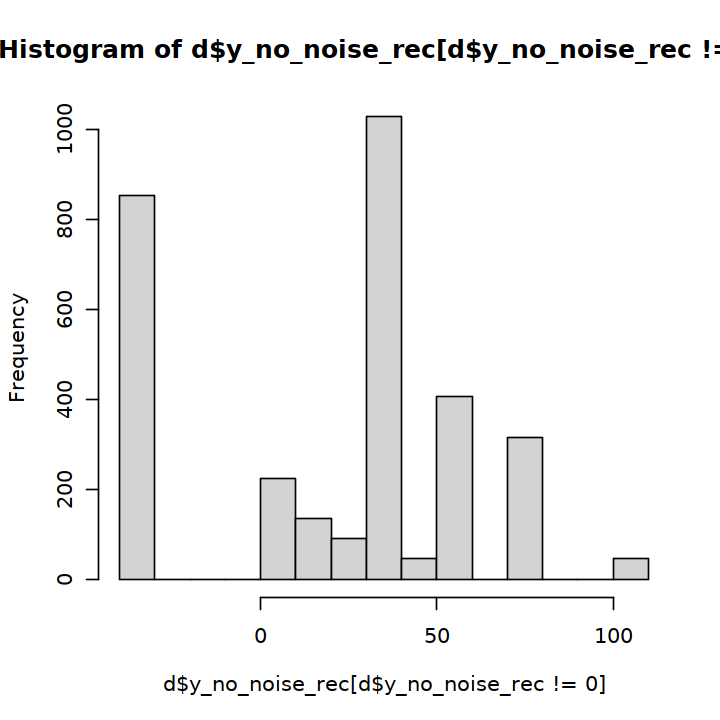

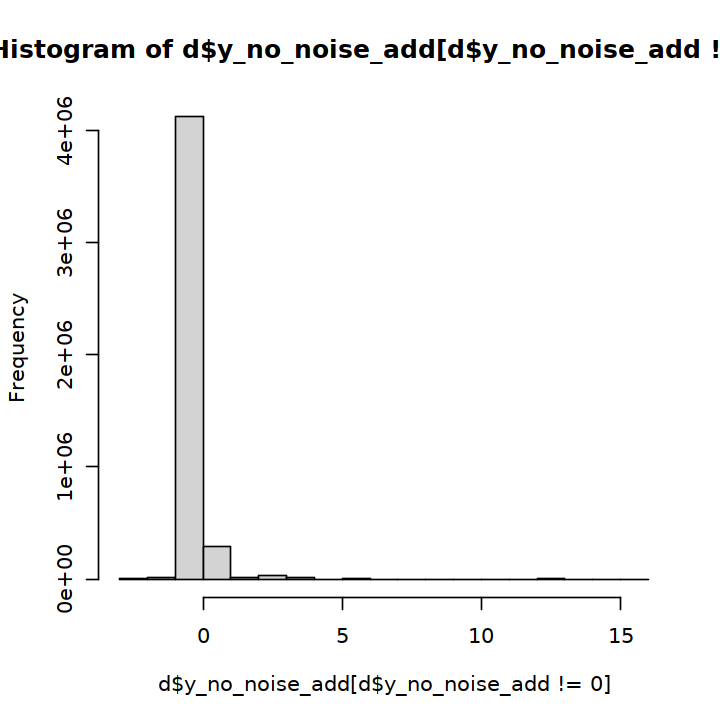

In [53]:
options(repr.plot.width=6, repr.plot.height=6)
hist(d$y_no_noise_rec[d$y_no_noise_rec != 0]);
hist(d$y_no_noise_add[d$y_no_noise_add != 0]);

In [ ]:
fread("data/")